# ***Analisis Sentimen multi-model pada konten 'podhub selesai disini': Studi komparatif algoritma machine learning***

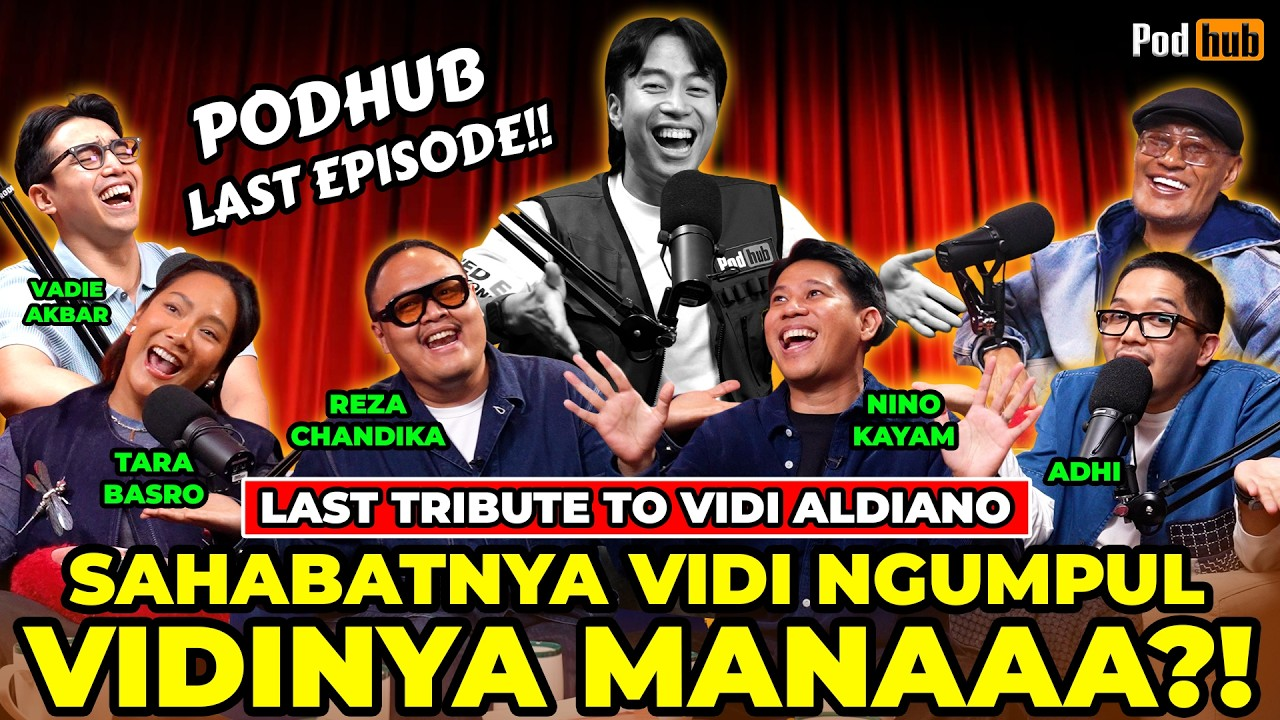

# ***CRAWLING DATA***

In [61]:
from googleapiclient.discovery import build
import csv
import pandas as pd

# Masukkan API Key yang didapat dari Google Cloud Console
api_key = '*****'
youtube = build('youtube', 'v3', developerKey=api_key)

# Fungsi untuk mengambil komentar dari video
def get_video_comments(video_id, max_comments):
    comments = []
    next_page_token = None

    while len(comments) < max_comments:
        response = youtube.commentThreads().list(
            part='snippet',
            videoId=video_id,
            maxResults=2000,
            textFormat='plainText',
            pageToken=next_page_token
        ).execute()

        for item in response['items']:
            if len(comments) >= max_comments:
                break
            comment = item['snippet']['topLevelComment']['snippet']['textDisplay']
            author = item['snippet']['topLevelComment']['snippet']['authorDisplayName']
            like_count = item['snippet']['topLevelComment']['snippet']['likeCount']
            published_at = item['snippet']['topLevelComment']['snippet']['publishedAt']

            comments.append({
                'author': author,
                'comment': comment,
                'likes': like_count,
                'published_at': published_at
            })

        next_page_token = response.get('nextPageToken')
        if not next_page_token:
            break

    return comments[:max_comments]

# Fungsi untuk menyimpan komentar ke file CSV
def save_comments_to_csv(comments, filename):
    with open(filename, mode='w', newline='', encoding='utf-8') as file:
        writer = csv.DictWriter(file, fieldnames=['author', 'comment', 'likes', 'published_at'])
        writer.writeheader()
        writer.writerows(comments)

# Fungsi utama untuk mengambil komentar dari beberapa video
def scrape_comments_from_videos(video_ids, total_comments, output_filename):
    all_comments = []
    comments_per_video = total_comments // len(video_ids)

    for video_id in video_ids:
        comments = get_video_comments(video_id, comments_per_video)
        all_comments.extend(comments)

    # Jika masih kurang, tambahkan sisanya dari video pertama
    if len(all_comments) < total_comments:
        extra_comments = total_comments - len(all_comments)
        extra_comments_from_first = get_video_comments(video_ids[0], extra_comments)
        all_comments.extend(extra_comments_from_first[:extra_comments])

    # Simpan hasilnya ke file CSV
    save_comments_to_csv(all_comments, output_filename)
    return all_comments

In [62]:
# ID video YouTube yang ingin diambil
video_ids = ['OiyTp7cq9ws']

total_comments = 13782
output_filename = 'dd.csv'

# Ambil komentar dan simpan ke file CSV
comments = scrape_comments_from_videos(video_ids, total_comments, output_filename)

df = pd.DataFrame(comments)
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13782 entries, 0 to 13781
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   author        13782 non-null  object
 1   comment       13782 non-null  object
 2   likes         13782 non-null  int64 
 3   published_at  13782 non-null  object
dtypes: int64(1), object(3)
memory usage: 430.8+ KB


,author,comment,likes,published_at
0,@nandanaboy2710,Udah sebln yang lalu dan w nonton lagi nangis ...,0,2026-05-10T16:24:00Z
1,@sajiniasaban1117,Kangen dengan ka vidi apalagi dengar suara ka ...,0,2026-05-10T12:56:14Z
2,@SriRahayu-f8r,"Kok sedihh ya,,tapi hidup memang terus berjalan",0,2026-05-10T10:14:16Z
3,@KumalaAfini,Cedih banget 😢😢😢😢😢,0,2026-05-10T07:54:06Z
4,@merrypoceratu7217,"Cerita sedihh d Balutt Komedii,,Hebatt Sahabt2...",0,2026-05-09T13:49:59Z


# ***TEXT PREPROCESSING DATA***

In [63]:
import pandas as pd
data = pd.read_csv("dd.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13782 entries, 0 to 13781
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   author        13782 non-null  object
 1   comment       13781 non-null  object
 2   likes         13782 non-null  int64 
 3   published_at  13782 non-null  object
dtypes: int64(1), object(3)
memory usage: 430.8+ KB


In [64]:
data.head()

,author,comment,likes,published_at
0,@nandanaboy2710,Udah sebln yang lalu dan w nonton lagi nangis ...,0,2026-05-10T16:24:00Z
1,@sajiniasaban1117,Kangen dengan ka vidi apalagi dengar suara ka ...,0,2026-05-10T12:56:14Z
2,@SriRahayu-f8r,"Kok sedihh ya,,tapi hidup memang terus berjalan",0,2026-05-10T10:14:16Z
3,@KumalaAfini,Cedih banget 😢😢😢😢😢,0,2026-05-10T07:54:06Z
4,@merrypoceratu7217,"Cerita sedihh d Balutt Komedii,,Hebatt Sahabt2...",0,2026-05-09T13:49:59Z


In [65]:
data.describe()

,likes
count,13782.000000
mean,1.622188
std,33.490505
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,2495.000000


In [66]:
# kolom dalam format datetime
data['published_at'] = pd.to_datetime(data['published_at'])

# Pisahkan tanggal dan waktu
data['date'] = data['published_at'].dt.date
data['time'] = data['published_at'].dt.time

data.head()

,author,comment,likes,published_at,date,time
0,@nandanaboy2710,Udah sebln yang lalu dan w nonton lagi nangis ...,0,2026-05-10 16:24:00+00:00,2026-05-10,16:24:00
1,@sajiniasaban1117,Kangen dengan ka vidi apalagi dengar suara ka ...,0,2026-05-10 12:56:14+00:00,2026-05-10,12:56:14
2,@SriRahayu-f8r,"Kok sedihh ya,,tapi hidup memang terus berjalan",0,2026-05-10 10:14:16+00:00,2026-05-10,10:14:16
3,@KumalaAfini,Cedih banget 😢😢😢😢😢,0,2026-05-10 07:54:06+00:00,2026-05-10,07:54:06
4,@merrypoceratu7217,"Cerita sedihh d Balutt Komedii,,Hebatt Sahabt2...",0,2026-05-09 13:49:59+00:00,2026-05-09,13:49:59


In [67]:
df  = pd.DataFrame(data[['comment']])
df.head(5)

,comment
0,Udah sebln yang lalu dan w nonton lagi nangis ...
1,Kangen dengan ka vidi apalagi dengar suara ka ...
2,"Kok sedihh ya,,tapi hidup memang terus berjalan"
3,Cedih banget 😢😢😢😢😢
4,"Cerita sedihh d Balutt Komedii,,Hebatt Sahabt2..."


**PROSES CLEANING**

---



In [68]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13782 entries, 0 to 13781
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   comment  13781 non-null  object
dtypes: object(1)
memory usage: 107.8+ KB


,comment
0,Udah sebln yang lalu dan w nonton lagi nangis ...
1,Kangen dengan ka vidi apalagi dengar suara ka ...
2,"Kok sedihh ya,,tapi hidup memang terus berjalan"
3,Cedih banget 😢😢😢😢😢
4,"Cerita sedihh d Balutt Komedii,,Hebatt Sahabt2..."


In [69]:
#mengecek data duplikat

data = df[df.duplicated(subset="comment", keep=False)]
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
Index: 893 entries, 38 to 13779
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   comment  893 non-null    object
dtypes: object(1)
memory usage: 14.0+ KB


,comment
38,😢
43,🤍
79,🥹🥹🥹
119,😢
171,😭😭😭😭😭😭😭😭😭


In [70]:
df.drop_duplicates(subset ="comment", inplace = True)

df.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
Index: 13047 entries, 0 to 13781
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   comment  13046 non-null  object
dtypes: object(1)
memory usage: 203.9+ KB


,comment
38,😢
43,🤍
79,🥹🥹🥹
119,😢
171,😭😭😭😭😭😭😭😭😭


In [71]:
import re
import string
import nltk

# Fungsi untuk menghapus URL
def remove_URL(tweet):
    if tweet is not None and isinstance(tweet, str):
        url = re.compile(r'https?://\S+|www\.\S+')
        return url.sub(r'', tweet)
    else:
        return tweet

# Fungsi untuk menghapus HTML
def remove_html(tweet):
    if tweet is not None and isinstance(tweet, str):
        html = re.compile(r'<.*?>')
        return html.sub(r'', tweet)
    else:
        return tweet

# Fungsi untuk menghapus emoji
def remove_emoji(tweet):
    if tweet is not None and isinstance(tweet, str):
        emoji_pattern = re.compile("["
            u"\U0001F600-\U0001F64F"  # emoticons
            u"\U0001F300-\U0001F5FF"  # symbols & pictographs
            u"\U0001F680-\U0001F6FF"  # transport & map symbols
            u"\U0001F700-\U0001F77F"  # alchemical symbols
            u"\U0001F780-\U0001F7FF"  # Geometric Shapes Extended
            u"\U0001F800-\U0001F8FF"  # Supplemental Arrows-C
            u"\U0001FA00-\U0001FA6F"  # Chess Symbols
            u"\U0001FA70-\U0001FAFF"  # Symbols and Pictographs Extended-A
            u"\U0001F004-\U0001F0CF"  # Additional emoticons
            u"\U0001F1E0-\U0001F1FF"  # flags
                               "]+", flags=re.UNICODE)
        return emoji_pattern.sub(r'', tweet)
    else:
        return tweet

# Fungsi untuk menghapus simbol
def remove_symbols(tweet):
    if tweet is not None and isinstance(tweet, str):
        tweet = re.sub(r'[^a-zA-Z0-9\s]', '', tweet)
    return tweet

# Fungsi untuk menghapus angka
def remove_numbers(tweet):
    if tweet is not None and isinstance(tweet, str):
        tweet = re.sub(r'\d', '', tweet)
    return tweet

# Fungsi hapus username
def remove_usernames(text):
    if text is not None and isinstance(text, str):
        return re.sub(r'@\w+', '', text)
    else:
        return text

df['cleaning'] = df['comment'].apply(lambda x: remove_URL(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_usernames(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_html(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_emoji(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_symbols(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_numbers(x))

df.head(5)

,comment,cleaning
0,Udah sebln yang lalu dan w nonton lagi nangis ...,Udah sebln yang lalu dan w nonton lagi nangis ...
1,Kangen dengan ka vidi apalagi dengar suara ka ...,Kangen dengan ka vidi apalagi dengar suara ka ...
2,"Kok sedihh ya,,tapi hidup memang terus berjalan",Kok sedihh yatapi hidup memang terus berjalan
3,Cedih banget 😢😢😢😢😢,Cedih banget
4,"Cerita sedihh d Balutt Komedii,,Hebatt Sahabt2...",Cerita sedihh d Balutt KomediiHebatt Sahabt Vidi


**PROSES CASE FOLDING**

---



In [72]:
def case_folding(text):
    if isinstance(text, str):
        lowercase_text = text.lower()
        return lowercase_text
    else:
        return text

df['case_folding'] = df['cleaning'].apply(case_folding)
df.head(5)

,comment,cleaning,case_folding
0,Udah sebln yang lalu dan w nonton lagi nangis ...,Udah sebln yang lalu dan w nonton lagi nangis ...,udah sebln yang lalu dan w nonton lagi nangis ...
1,Kangen dengan ka vidi apalagi dengar suara ka ...,Kangen dengan ka vidi apalagi dengar suara ka ...,kangen dengan ka vidi apalagi dengar suara ka ...
2,"Kok sedihh ya,,tapi hidup memang terus berjalan",Kok sedihh yatapi hidup memang terus berjalan,kok sedihh yatapi hidup memang terus berjalan
3,Cedih banget 😢😢😢😢😢,Cedih banget,cedih banget
4,"Cerita sedihh d Balutt Komedii,,Hebatt Sahabt2...",Cerita sedihh d Balutt KomediiHebatt Sahabt Vidi,cerita sedihh d balutt komediihebatt sahabt vidi


**Normalisasi Kata**

---



In [73]:
import pandas as pd
import requests
from io import BytesIO

# Fungsi penggantian kata tidak baku
def replace_taboo_words(text, kamus_tidak_baku):
    if isinstance(text, str):
        words = text.split()
        replaced_words = []
        kalimat_baku = []
        kata_diganti = []
        kata_tidak_baku_hash = []

        for word in words:
            if word in kamus_tidak_baku:
                baku_word = kamus_tidak_baku[word]
                if isinstance(baku_word, str) and all(char.isalpha() for char in baku_word):
                    replaced_words.append(baku_word)
                    kalimat_baku.append(baku_word)
                    kata_diganti.append(word)
                    kata_tidak_baku_hash.append(hash(word))
            else:
                replaced_words.append(word)
        replaced_text = ' '.join(replaced_words)
    else:
        replaced_text = ''
        kalimat_baku = []
        kata_diganti = []
        kata_tidak_baku_hash = []

    return replaced_text, kalimat_baku, kata_diganti, kata_tidak_baku_hash

data = pd.DataFrame(df[['comment','cleaning','case_folding']])
data.head()

,comment,cleaning,case_folding
0,Udah sebln yang lalu dan w nonton lagi nangis ...,Udah sebln yang lalu dan w nonton lagi nangis ...,udah sebln yang lalu dan w nonton lagi nangis ...
1,Kangen dengan ka vidi apalagi dengar suara ka ...,Kangen dengan ka vidi apalagi dengar suara ka ...,kangen dengan ka vidi apalagi dengar suara ka ...
2,"Kok sedihh ya,,tapi hidup memang terus berjalan",Kok sedihh yatapi hidup memang terus berjalan,kok sedihh yatapi hidup memang terus berjalan
3,Cedih banget 😢😢😢😢😢,Cedih banget,cedih banget
4,"Cerita sedihh d Balutt Komedii,,Hebatt Sahabt2...",Cerita sedihh d Balutt KomediiHebatt Sahabt Vidi,cerita sedihh d balutt komediihebatt sahabt vidi


In [74]:
# Unduh dan baca kamus dari GitHub
url = "https://github.com/analysisdatasentiment/kamus_kata_baku/raw/main/kamuskatabaku.xlsx"
response = requests.get(url)
file_excel = BytesIO(response.content)
kamus_data = pd.read_excel(file_excel)

# Buat dictionary dari kamus
kamus_tidak_baku_dict = dict(zip(kamus_data['tidak_baku'], kamus_data['kata_baku']))

In [75]:
# Terapkan fungsi normalisasi
data[['normalisasi', 'Kata_Baku', 'Kata_Tidak_Baku', 'Kata_Tidak_Baku_Hash']] = data['case_folding'].apply(
    lambda x: pd.Series(replace_taboo_words(x, kamus_tidak_baku_dict))
)

# Ambil kolom yang relevan
df = pd.DataFrame(data[['comment','cleaning','case_folding','normalisasi']])
df.head(5)

,comment,cleaning,case_folding,normalisasi
0,Udah sebln yang lalu dan w nonton lagi nangis ...,Udah sebln yang lalu dan w nonton lagi nangis ...,udah sebln yang lalu dan w nonton lagi nangis ...,sudah sebln yang lalu dan gue menonton lagi me...
1,Kangen dengan ka vidi apalagi dengar suara ka ...,Kangen dengan ka vidi apalagi dengar suara ka ...,kangen dengan ka vidi apalagi dengar suara ka ...,kangen dengan kak vidi apalagi dengar suara ka...
2,"Kok sedihh ya,,tapi hidup memang terus berjalan",Kok sedihh yatapi hidup memang terus berjalan,kok sedihh yatapi hidup memang terus berjalan,kok sedih yatapi hidup memang terus berjalan
3,Cedih banget 😢😢😢😢😢,Cedih banget,cedih banget,cedih banget
4,"Cerita sedihh d Balutt Komedii,,Hebatt Sahabt2...",Cerita sedihh d Balutt KomediiHebatt Sahabt Vidi,cerita sedihh d balutt komediihebatt sahabt vidi,cerita sedih di balutt komediihebatt sahabt vidi


**TOKENIZATION**

---



In [76]:
def tokenize(text):
    tokens = text.split()
    return tokens

df['tokenize'] = df['normalisasi'].apply(tokenize)

df.head(5)

,comment,cleaning,case_folding,normalisasi,tokenize
0,Udah sebln yang lalu dan w nonton lagi nangis ...,Udah sebln yang lalu dan w nonton lagi nangis ...,udah sebln yang lalu dan w nonton lagi nangis ...,sudah sebln yang lalu dan gue menonton lagi me...,"[sudah, sebln, yang, lalu, dan, gue, menonton,..."
1,Kangen dengan ka vidi apalagi dengar suara ka ...,Kangen dengan ka vidi apalagi dengar suara ka ...,kangen dengan ka vidi apalagi dengar suara ka ...,kangen dengan kak vidi apalagi dengar suara ka...,"[kangen, dengan, kak, vidi, apalagi, dengar, s..."
2,"Kok sedihh ya,,tapi hidup memang terus berjalan",Kok sedihh yatapi hidup memang terus berjalan,kok sedihh yatapi hidup memang terus berjalan,kok sedih yatapi hidup memang terus berjalan,"[kok, sedih, yatapi, hidup, memang, terus, ber..."
3,Cedih banget 😢😢😢😢😢,Cedih banget,cedih banget,cedih banget,"[cedih, banget]"
4,"Cerita sedihh d Balutt Komedii,,Hebatt Sahabt2...",Cerita sedihh d Balutt KomediiHebatt Sahabt Vidi,cerita sedihh d balutt komediihebatt sahabt vidi,cerita sedih di balutt komediihebatt sahabt vidi,"[cerita, sedih, di, balutt, komediihebatt, sah..."


**PROSES STOPWORD REMOVAL**

---



In [77]:
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = stopwords.words('indonesian')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [78]:
def remove_stopwords(text):
    return [word for word in text if word not in stop_words]

# Ubah hasil list jadi string
df['stopword removal'] = df['tokenize'].apply(
    lambda x: " ".join(remove_stopwords(x))
)

df.head(5)

,comment,cleaning,case_folding,normalisasi,tokenize,stopword removal
0,Udah sebln yang lalu dan w nonton lagi nangis ...,Udah sebln yang lalu dan w nonton lagi nangis ...,udah sebln yang lalu dan w nonton lagi nangis ...,sudah sebln yang lalu dan gue menonton lagi me...,"[sudah, sebln, yang, lalu, dan, gue, menonton,...",sebln gue menonton menangis aduhhhh terserah d...
1,Kangen dengan ka vidi apalagi dengar suara ka ...,Kangen dengan ka vidi apalagi dengar suara ka ...,kangen dengan ka vidi apalagi dengar suara ka ...,kangen dengan kak vidi apalagi dengar suara ka...,"[kangen, dengan, kak, vidi, apalagi, dengar, s...",kangen kak vidi dengar suara kak vadi
2,"Kok sedihh ya,,tapi hidup memang terus berjalan",Kok sedihh yatapi hidup memang terus berjalan,kok sedihh yatapi hidup memang terus berjalan,kok sedih yatapi hidup memang terus berjalan,"[kok, sedih, yatapi, hidup, memang, terus, ber...",sedih yatapi hidup berjalan
3,Cedih banget 😢😢😢😢😢,Cedih banget,cedih banget,cedih banget,"[cedih, banget]",cedih banget
4,"Cerita sedihh d Balutt Komedii,,Hebatt Sahabt2...",Cerita sedihh d Balutt KomediiHebatt Sahabt Vidi,cerita sedihh d balutt komediihebatt sahabt vidi,cerita sedih di balutt komediihebatt sahabt vidi,"[cerita, sedih, di, balutt, komediihebatt, sah...",cerita sedih balutt komediihebatt sahabt vidi


In [79]:
from collections import Counter

all_text = ' '.join(df['stopword removal'].astype(str))
all_text = re.sub(r'[^a-zA-Z\s]', '', all_text.lower())

word_list = all_text.split()
word_freq = Counter(word_list)

sorted_freq = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)
df_freq = pd.DataFrame(sorted_freq, columns=['Kata', 'Frekuensi'])

df_freq.to_csv('frekuensi_kata_awal.csv', index=False)
print("✅ File 'frekuensi_kata_awal.csv' berhasil disimpan.")
df_freq.info()
df_freq.head(50)

✅ File 'frekuensi_kata_awal.csv' berhasil disimpan.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13681 entries, 0 to 13680
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Kata       13681 non-null  object
 1   Frekuensi  13681 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 213.9+ KB


,Kata,Frekuensi
0,vidi,7880
1,podhub,4115
2,banget,3755
3,ya,3205
4,menangis,3126
5,kak,2832
6,menonton,2633
7,om,2607
8,gue,1798
9,ketawa,1787


In [80]:
hapus_kata = ['ya','tok','deh','wok','we','the','loh','sih',
              'roy','not','nih','cs','y','abang','bang','gue',
              'lo','kau','sok','ku','bu','tuh','gua','kak',
              'ya','om','ded','gue','you','vid','sih','thank','lu','tau','al','gua']

# hapus kata dari teks
df['stopword removal'] = df['stopword removal'].apply(
    lambda x: ' '.join([kata for kata in x.split() if kata not in hapus_kata]))

df['stopword removal'].str.contains('|'.join(hapus_kata)).sum()

np.int64(10543)

In [81]:
# ---  Membuat kamus kata tidak baku -> kata baku
kamus_tidak_baku = {
    'apk':'aplikasi',
    'app':'aplikasi',
    'hp':'handphone'
}

def perbaiki_kata(teks):
    kata_list = teks.split()
    hasil = [kamus_tidak_baku.get(kata, kata) for kata in kata_list]
    return ' '.join(hasil)

df['stopword removal'] = df['stopword removal'].astype(str).apply(perbaiki_kata)

In [82]:
from collections import Counter
import re

all_text = ' '.join(df['stopword removal'].astype(str))
all_text = re.sub(r'[^a-zA-Z\s]', '', all_text.lower())

word_list = all_text.split()
word_freq = Counter(word_list)

sorted_freq = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)
df_freq = pd.DataFrame(sorted_freq, columns=['Kata', 'Frekuensi'])

# df_freq.info()
df_freq.head(50)

,Kata,Frekuensi
0,vidi,7880
1,podhub,4115
2,banget,3755
3,menangis,3126
4,menonton,2633
5,ketawa,1787
6,orang,1142
7,sedih,1081
8,lihat,899
9,almarhum,821


**WORDCLOUD SETELAH PREPROCESSING**

---



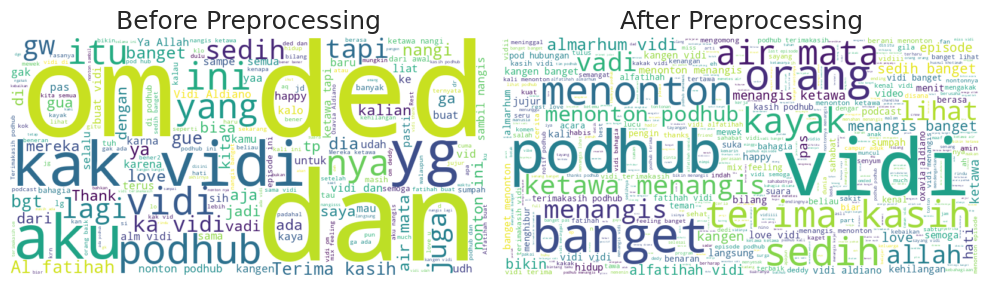

In [83]:
import pandas as pd
import numpy as np
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt

# Buat stopwords tambahan
stopwords = set(STOPWORDS)
stopwords.update(['https', 'co', 'RT', '...', 'amp', 'lu','jokowi'])

# WordCloud Before
text_before = ' '.join(
    df['comment']
    .astype(str)
    .tolist()
)

wc_before = WordCloud(
    stopwords=stopwords,
    background_color="white",
    max_words=200,
    width=800,
    height=400
).generate(text_before)

# WordCloud After (dari kolom 'stopword removal')
text_after = ' '.join(
    [" ".join(eval(x) if isinstance(x, str) and x.startswith('[') else x.split())
     for x in df['stopword removal'].astype(str)]
)

wc_after = WordCloud(
    stopwords=stopwords,
    background_color="white",
    max_words=1000,
    width=800,
    height=400
).generate(text_after)

# Visualisasi side-by-side
plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
plt.imshow(wc_before, interpolation='bilinear')
plt.axis("off")
plt.title("Before Preprocessing", fontsize=18)

plt.subplot(1, 2, 2)
plt.imshow(wc_after, interpolation='bilinear')
plt.axis("off")
plt.title("After Preprocessing", fontsize=18)

plt.tight_layout()
plt.show()

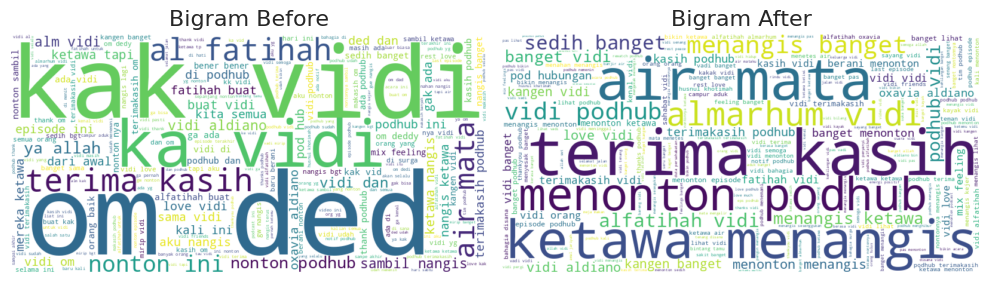

In [84]:
import pandas as pd
import numpy as np
from PIL import Image
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

# Stopwords tambahan
stopwords = set(STOPWORDS)
stopwords.update(['https', 'co', 'RT', '...', 'amp', 'lu','jokowi'])

# =========================
# BEFORE (BIGRAM)
# =========================
text_before = df['comment'].astype(str)

vectorizer_before = CountVectorizer(
    stop_words=list(stopwords),
    ngram_range=(2,2)  # BIGRAM
)

X_before = vectorizer_before.fit_transform(text_before)
sum_words_before = X_before.sum(axis=0)

words_freq_before = [
    (word, sum_words_before[0, idx])
    for word, idx in vectorizer_before.vocabulary_.items()
]

# Convert ke dict
freq_dict_before = dict(words_freq_before)

wc_before = WordCloud(
    background_color="white",
    width=800,
    height=400
).generate_from_frequencies(freq_dict_before)

# =========================
# AFTER (BIGRAM)
# =========================
text_after = [
    " ".join(eval(x) if isinstance(x, str) and x.startswith('[') else x.split())
    for x in df['stopword removal'].astype(str)
]

vectorizer_after = CountVectorizer(
    stop_words=list(stopwords),
    ngram_range=(2,2)  # BIGRAM
)

X_after = vectorizer_after.fit_transform(text_after)
sum_words_after = X_after.sum(axis=0)

words_freq_after = [
    (word, sum_words_after[0, idx])
    for word, idx in vectorizer_after.vocabulary_.items()
]

freq_dict_after = dict(words_freq_after)

wc_after = WordCloud(
    background_color="white",
    width=800,
    height=400
).generate_from_frequencies(freq_dict_after)

# =========================
# VISUALISASI
# =========================
plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
plt.imshow(wc_before, interpolation='bilinear')
plt.axis("off")
plt.title("Bigram Before", fontsize=16)

plt.subplot(1, 2, 2)
plt.imshow(wc_after, interpolation='bilinear')
plt.axis("off")
plt.title("Bigram After", fontsize=16)

plt.tight_layout()
plt.show()

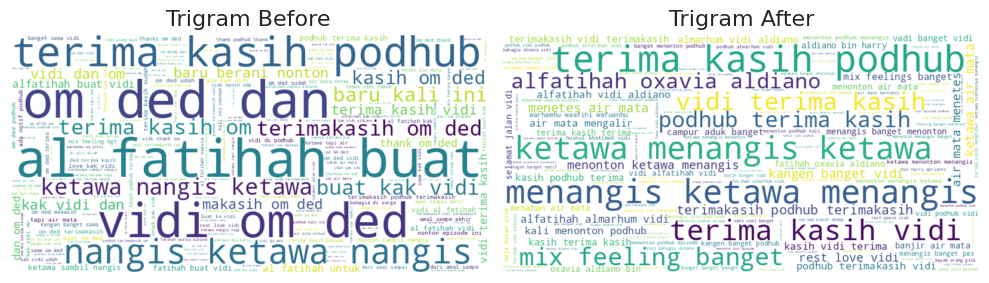

In [85]:
import pandas as pd
import numpy as np
from PIL import Image
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

# Stopwords tambahan
stopwords = set(STOPWORDS)
stopwords.update(['https', 'co', 'RT', '...', 'amp', 'lu','jokowi'])

# =========================
# BEFORE (TRIGRAM)
# =========================
text_before = df['comment'].astype(str)

vectorizer_before = CountVectorizer(
    stop_words=list(stopwords),
    ngram_range=(3,3)  # TRIGRAM
)

X_before = vectorizer_before.fit_transform(text_before)
sum_words_before = X_before.sum(axis=0)

words_freq_before = [
    (word, sum_words_before[0, idx])
    for word, idx in vectorizer_before.vocabulary_.items()
]

# Convert ke dict
freq_dict_before = dict(words_freq_before)

wc_before = WordCloud(
    background_color="white",
    width=800,
    height=400
).generate_from_frequencies(freq_dict_before)

# =========================
# AFTER (TRIGRAM)
# =========================
text_after = [
    " ".join(eval(x) if isinstance(x, str) and x.startswith('[') else x.split())
    for x in df['stopword removal'].astype(str)
]

vectorizer_after = CountVectorizer(
    stop_words=list(stopwords),
    ngram_range=(3,3)  # TRIGRAM
)

X_after = vectorizer_after.fit_transform(text_after)
sum_words_after = X_after.sum(axis=0)

words_freq_after = [
    (word, sum_words_after[0, idx])
    for word, idx in vectorizer_after.vocabulary_.items()
]

freq_dict_after = dict(words_freq_after)

wc_after = WordCloud(
    background_color="white",
    width=800,
    height=400
).generate_from_frequencies(freq_dict_after)

# =========================
# VISUALISASI
# =========================
plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
plt.imshow(wc_before, interpolation='bilinear')
plt.axis("off")
plt.title("Trigram Before", fontsize=16)

plt.subplot(1, 2, 2)
plt.imshow(wc_after, interpolation='bilinear')
plt.axis("off")
plt.title("Trigram After", fontsize=16)

plt.tight_layout()
plt.show()

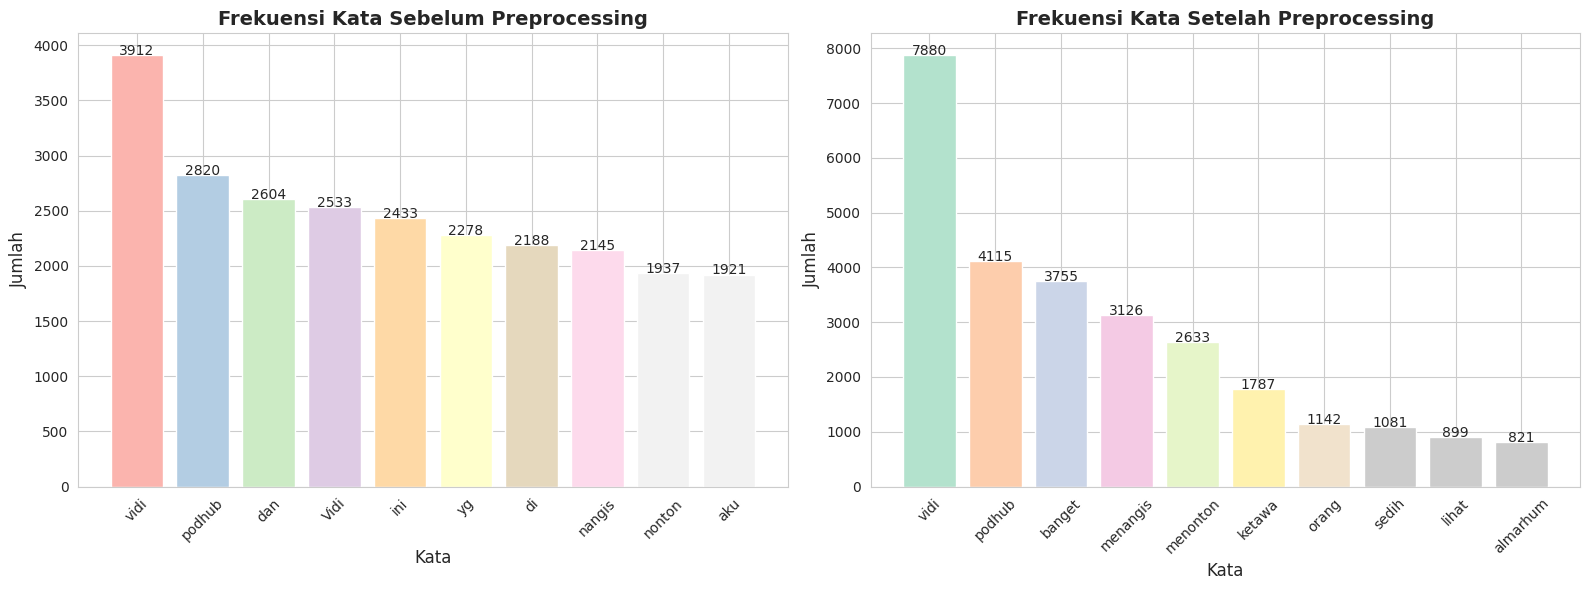

In [86]:
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import STOPWORDS
import re

# Set stopwords tambahan
stopwords = set(STOPWORDS)
stopwords.update(['https', 'co', 'RT', '...', 'amp', 'lu'])

# Fungsi helper untuk membersihkan tanda kutip, [ ], , dll
def clean_text_column(series):
    cleaned = []
    for text in series.astype(str):
        # Hapus [ ], tanda petik tunggal/ganda, koma
        text = re.sub(r"[\[\]\'\",]", "", text)
        cleaned.append(text.strip())
    return " ".join(cleaned)

# BEFORE
all_text_before = clean_text_column(df["comment"])
words_before = all_text_before.split()
filtered_words_before = [word for word in words_before if word.lower() not in stopwords]
word_counts_before = Counter(filtered_words_before)
top_words_before = word_counts_before.most_common(10)
word_before, count_before = zip(*top_words_before)

# AFTER
all_text_after = clean_text_column(df["stopword removal"])
words_after = all_text_after.split()
filtered_words_after = [word for word in words_after if word.lower() not in stopwords]
word_counts_after = Counter(filtered_words_after)
top_words_after = word_counts_after.most_common(10)
word_after, count_after = zip(*top_words_after)

# Plot berdampingan
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# BEFORE Plot
colors_before = plt.cm.Pastel1(range(len(word_before)))
bars1 = axes[0].bar(word_before, count_before, color=colors_before)
axes[0].set_title("Frekuensi Kata Sebelum Preprocessing", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Kata", fontsize=12)
axes[0].set_ylabel("Jumlah", fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
for bar, count in zip(bars1, count_before):
    axes[0].text(bar.get_x() + bar.get_width()/2, count + 1, str(count), ha='center')

# AFTER Plot
colors_after = plt.cm.Pastel2(range(len(word_after)))
bars2 = axes[1].bar(word_after, count_after, color=colors_after)
axes[1].set_title("Frekuensi Kata Setelah Preprocessing", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Kata", fontsize=12)
axes[1].set_ylabel("Jumlah", fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
for bar, count in zip(bars2, count_after):
    axes[1].text(bar.get_x() + bar.get_width()/2, count + 1, str(count), ha='center')

plt.tight_layout()
plt.show()

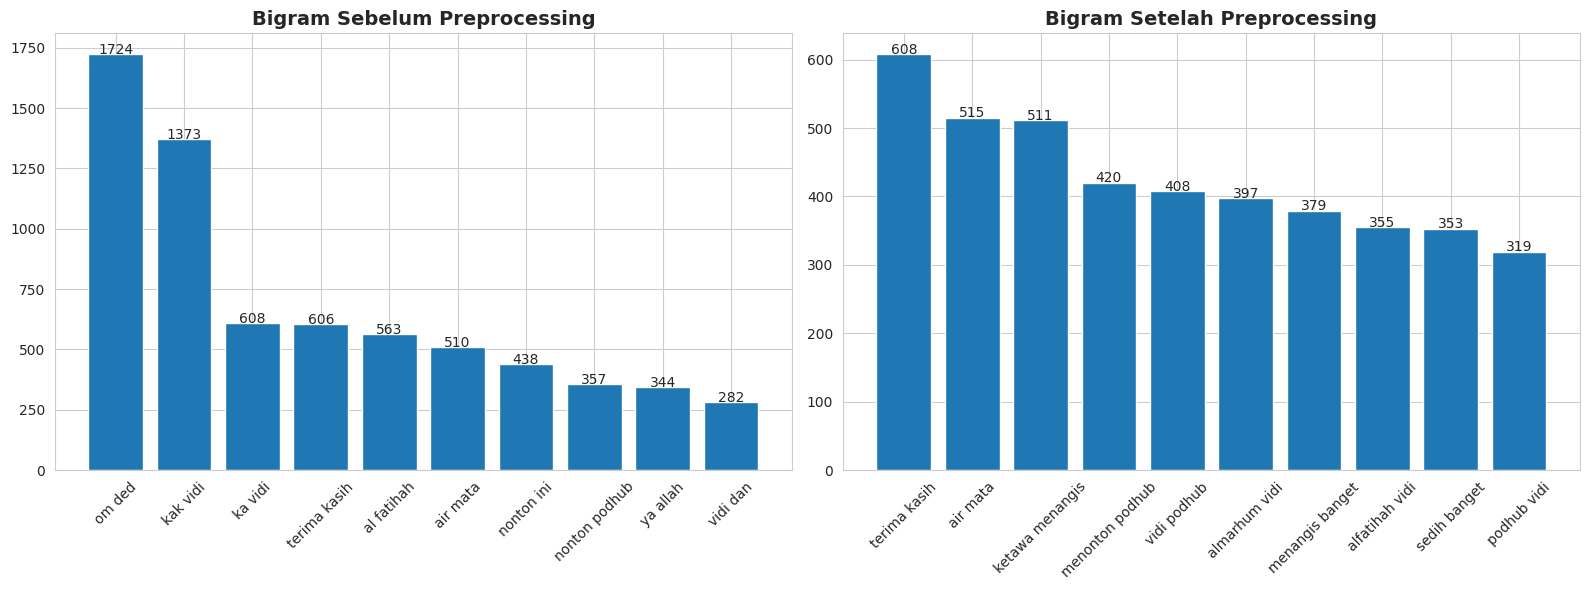

In [87]:
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import STOPWORDS
import re

# Stopwords tambahan
stopwords = set(STOPWORDS)
stopwords.update(['https', 'co', 'RT', '...', 'amp', 'lu'])

# Fungsi cleaning
def clean_text_column(series):
    cleaned = []
    for text in series.astype(str):
        text = re.sub(r"[\[\]\'\",]", "", text)
        cleaned.append(text.strip())
    return " ".join(cleaned)

# =========================
# BEFORE (BIGRAM)
# =========================
text_before = clean_text_column(df["comment"])

vectorizer_before = CountVectorizer(
    ngram_range=(2,2),  # BIGRAM
    stop_words=list(stopwords)
)

X_before = vectorizer_before.fit_transform([text_before])
bigram_before = vectorizer_before.get_feature_names_out()
counts_before = X_before.toarray().flatten()

# Ambil top 10
top_idx_before = counts_before.argsort()[-10:][::-1]
top_bigram_before = bigram_before[top_idx_before]
top_count_before = counts_before[top_idx_before]

# =========================
# AFTER (BIGRAM)
# =========================
text_after = clean_text_column(df["stopword removal"])

vectorizer_after = CountVectorizer(
    ngram_range=(2,2),
    stop_words=list(stopwords)
)

X_after = vectorizer_after.fit_transform([text_after])
bigram_after = vectorizer_after.get_feature_names_out()
counts_after = X_after.toarray().flatten()

# Ambil top 10
top_idx_after = counts_after.argsort()[-10:][::-1]
top_bigram_after = bigram_after[top_idx_after]
top_count_after = counts_after[top_idx_after]

# =========================
# PLOT
# =========================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# BEFORE
bars1 = axes[0].bar(top_bigram_before, top_count_before)
axes[0].set_title("Bigram Sebelum Preprocessing", fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

for bar, count in zip(bars1, top_count_before):
    axes[0].text(bar.get_x() + bar.get_width()/2, count + 0.5, str(count), ha='center')

# AFTER
bars2 = axes[1].bar(top_bigram_after, top_count_after)
axes[1].set_title("Bigram Setelah Preprocessing", fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

for bar, count in zip(bars2, top_count_after):
    axes[1].text(bar.get_x() + bar.get_width()/2, count + 0.5, str(count), ha='center')

plt.tight_layout()
plt.show()

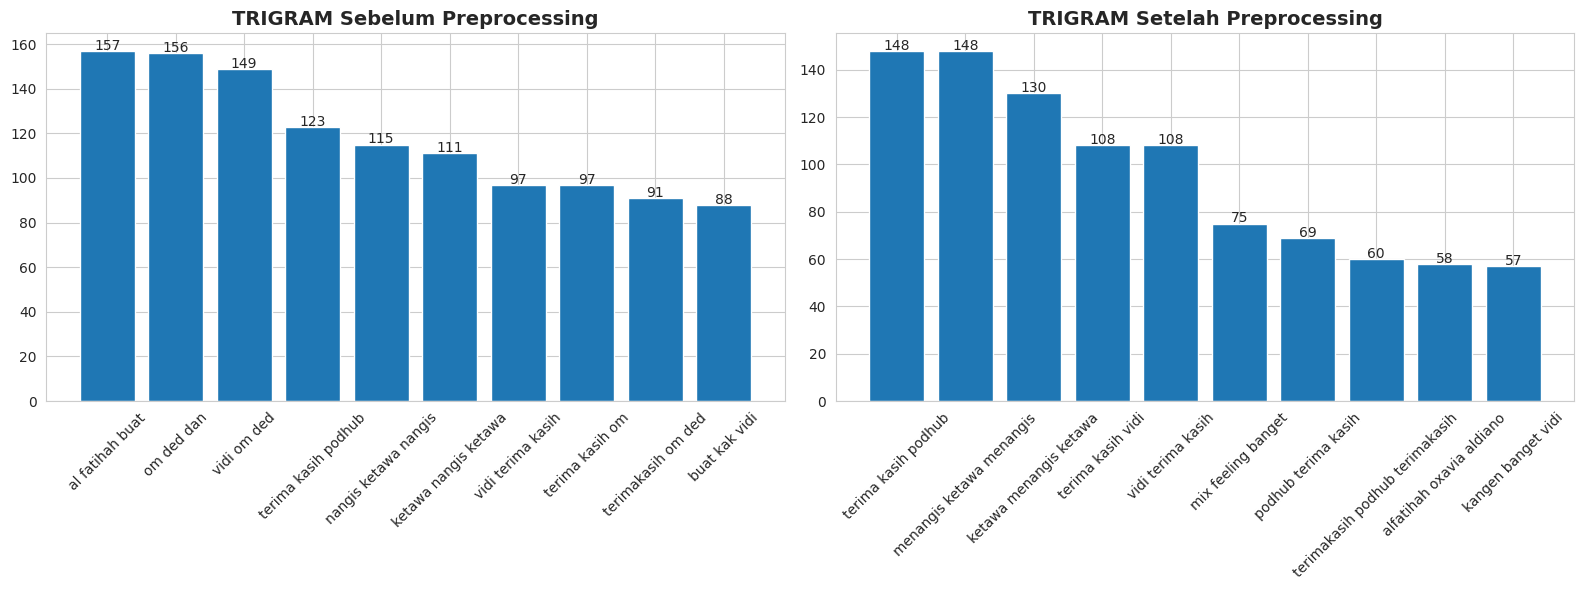

In [88]:
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import STOPWORDS
import re

# Stopwords tambahan
stopwords = set(STOPWORDS)
stopwords.update(['https', 'co', 'RT', '...', 'amp', 'lu'])

# Fungsi cleaning
def clean_text_column(series):
    cleaned = []
    for text in series.astype(str):
        text = re.sub(r"[\[\]\'\",]", "", text)
        cleaned.append(text.strip())
    return " ".join(cleaned)

# =========================
# BEFORE (TRIGRAM)
# =========================
text_before = clean_text_column(df["comment"])

vectorizer_before = CountVectorizer(
    ngram_range=(3,3),  # TRIGRAM
    stop_words=list(stopwords)
)

X_before = vectorizer_before.fit_transform([text_before])
bigram_before = vectorizer_before.get_feature_names_out()
counts_before = X_before.toarray().flatten()

# Ambil top 10
top_idx_before = counts_before.argsort()[-10:][::-1]
top_bigram_before = bigram_before[top_idx_before]
top_count_before = counts_before[top_idx_before]

# =========================
# AFTER (TRIGRAM)
# =========================
text_after = clean_text_column(df["stopword removal"])

vectorizer_after = CountVectorizer(
    ngram_range=(3,3),
    stop_words=list(stopwords)
)

X_after = vectorizer_after.fit_transform([text_after])
bigram_after = vectorizer_after.get_feature_names_out()
counts_after = X_after.toarray().flatten()

# Ambil top 10
top_idx_after = counts_after.argsort()[-10:][::-1]
top_bigram_after = bigram_after[top_idx_after]
top_count_after = counts_after[top_idx_after]

# =========================
# PLOT
# =========================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# BEFORE
bars1 = axes[0].bar(top_bigram_before, top_count_before)
axes[0].set_title("TRIGRAM Sebelum Preprocessing", fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

for bar, count in zip(bars1, top_count_before):
    axes[0].text(bar.get_x() + bar.get_width()/2, count + 0.5, str(count), ha='center')

# AFTER
bars2 = axes[1].bar(top_bigram_after, top_count_after)
axes[1].set_title("TRIGRAM Setelah Preprocessing", fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

for bar, count in zip(bars2, top_count_after):
    axes[1].text(bar.get_x() + bar.get_width()/2, count + 0.5, str(count), ha='center')

plt.tight_layout()
plt.show()

In [89]:
df.to_csv('Hasil_Preprocessing_Data.csv',encoding='utf8', index=False);

# ***PELEBELAN DATA METODE LAXICON BASED 2 CLASS***

In [90]:
import pandas as pd

data = pd.read_csv("Hasil_Preprocessing_Data.csv")
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13047 entries, 0 to 13046
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   comment           13046 non-null  object
 1   cleaning          12717 non-null  object
 2   case_folding      12717 non-null  object
 3   normalisasi       12692 non-null  object
 4   tokenize          13047 non-null  object
 5   stopword removal  12630 non-null  object
dtypes: object(6)
memory usage: 611.7+ KB


,comment,cleaning,case_folding,normalisasi,tokenize,stopword removal
0,Udah sebln yang lalu dan w nonton lagi nangis ...,Udah sebln yang lalu dan w nonton lagi nangis ...,udah sebln yang lalu dan w nonton lagi nangis ...,sudah sebln yang lalu dan gue menonton lagi me...,"['sudah', 'sebln', 'yang', 'lalu', 'dan', 'gue...",sebln menonton menangis aduhhhh terserah bilan...
1,Kangen dengan ka vidi apalagi dengar suara ka ...,Kangen dengan ka vidi apalagi dengar suara ka ...,kangen dengan ka vidi apalagi dengar suara ka ...,kangen dengan kak vidi apalagi dengar suara ka...,"['kangen', 'dengan', 'kak', 'vidi', 'apalagi',...",kangen vidi dengar suara vadi
2,"Kok sedihh ya,,tapi hidup memang terus berjalan",Kok sedihh yatapi hidup memang terus berjalan,kok sedihh yatapi hidup memang terus berjalan,kok sedih yatapi hidup memang terus berjalan,"['kok', 'sedih', 'yatapi', 'hidup', 'memang', ...",sedih yatapi hidup berjalan
3,Cedih banget 😢😢😢😢😢,Cedih banget,cedih banget,cedih banget,"['cedih', 'banget']",cedih banget
4,"Cerita sedihh d Balutt Komedii,,Hebatt Sahabt2...",Cerita sedihh d Balutt KomediiHebatt Sahabt Vidi,cerita sedihh d balutt komediihebatt sahabt vidi,cerita sedih di balutt komediihebatt sahabt vidi,"['cerita', 'sedih', 'di', 'balutt', 'komediihe...",cerita sedih balutt komediihebatt sahabt vidi


In [91]:
data = pd.DataFrame(data[['stopword removal']])
data.info()
data.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13047 entries, 0 to 13046
Data columns (total 1 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   stopword removal  12630 non-null  object
dtypes: object(1)
memory usage: 102.1+ KB


,stopword removal
0,sebln menonton menangis aduhhhh terserah bilan...
1,kangen vidi dengar suara vadi
2,sedih yatapi hidup berjalan
3,cedih banget
4,cerita sedih balutt komediihebatt sahabt vidi


In [92]:
import pandas as pd
import requests

# Unduh kamus leksikon positif dan negatif dari GitHub
positive_url = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
negative_url = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"

positive_lexicon = set(pd.read_csv(positive_url, sep="\t", header=None)[0])
negative_lexicon = set(pd.read_csv(negative_url, sep="\t", header=None)[0])

def determine_sentiment(text):
    if isinstance(text, str):
        positive_count = sum(1 for word in text.split() if word in positive_lexicon)
        negative_count = sum(1 for word in text.split() if word in negative_lexicon)
        sentiment_score = positive_count - negative_count
        sentiment = "Negatif" if sentiment_score < 0 else "Positif"
        return sentiment_score, sentiment
    return 0, "Negatif"

data[['Score', 'Sentiment']] = data['stopword removal'].apply(lambda x: pd.Series(determine_sentiment(x)))
data.head(20)


,stopword removal,Score,Sentiment
0,sebln menonton menangis aduhhhh terserah bilan...,-7,Negatif
1,kangen vidi dengar suara vadi,1,Positif
2,sedih yatapi hidup berjalan,-1,Negatif
3,cedih banget,0,Positif
4,cerita sedih balutt komediihebatt sahabt vidi,-1,Negatif
5,omg menangis guys,0,Positif
6,menangis banget,0,Positif
7,menahan menangis menonton menetes air mata,-5,Negatif
8,jujur berani menonton,0,Positif
9,menonton,0,Positif


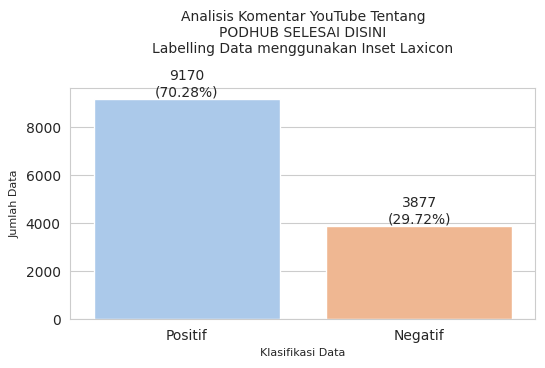

In [93]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sentiment_count = data['Sentiment'].value_counts()
sns.set_style('whitegrid')

fig, ax = plt.subplots(figsize=(6, 3))
ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette='pastel')
plt.title('Analisis Komentar YouTube Tentang\nPODHUB SELESAI DISINI\nLabelling Data menggunakan Inset Laxicon', fontsize=10, pad=25)
plt.xlabel('Klasifikasi Data', fontsize=8)
plt.ylabel('Jumlah Data', fontsize=8)

total = len(data['Sentiment'])

for i, count in enumerate(sentiment_count.values):
    percentage = f'{100 * count / total:.2f}%'
    ax.text(i, count + 0.10, f'{count}\n({percentage})', ha='center', va='bottom')

plt.show()

In [94]:
data.to_csv('Hasil_Labelling_Data_Inset_Lax.csv',encoding='utf8', index=False)

# ***WORDCLOUD & FREKUENSI KATA NGRAM***

In [95]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud

# Ganti dengan path dataset kamu
df = pd.read_csv("Hasil_Labelling_Data_Inset_Lax.csv")

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13047 entries, 0 to 13046
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   stopword removal  12630 non-null  object
 1   Score             13047 non-null  int64 
 2   Sentiment         13047 non-null  object
dtypes: int64(1), object(2)
memory usage: 305.9+ KB


,stopword removal,Score,Sentiment
0,sebln menonton menangis aduhhhh terserah bilan...,-7,Negatif
1,kangen vidi dengar suara vadi,1,Positif
2,sedih yatapi hidup berjalan,-1,Negatif
3,cedih banget,0,Positif
4,cerita sedih balutt komediihebatt sahabt vidi,-1,Negatif


In [96]:
# Pastikan tidak ada nilai kosong
df = df.dropna(subset=['stopword removal', 'Sentiment'])
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 12630 entries, 0 to 13046
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   stopword removal  12630 non-null  object
 1   Score             12630 non-null  int64 
 2   Sentiment         12630 non-null  object
dtypes: int64(1), object(2)
memory usage: 394.7+ KB


,stopword removal,Score,Sentiment
0,sebln menonton menangis aduhhhh terserah bilan...,-7,Negatif
1,kangen vidi dengar suara vadi,1,Positif
2,sedih yatapi hidup berjalan,-1,Negatif
3,cedih banget,0,Positif
4,cerita sedih balutt komediihebatt sahabt vidi,-1,Negatif


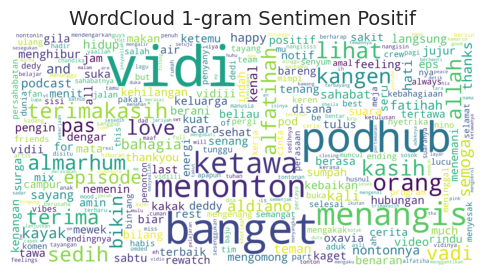

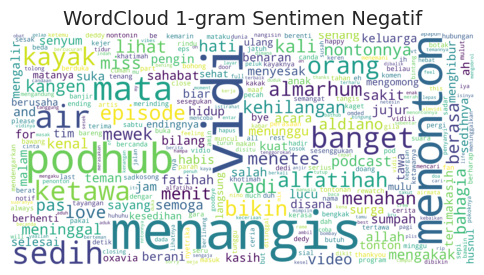

In [97]:
def wordcloud_ngram(data, sentiment_label, ngram_range=(2,3), max_words=1000):
    text_data = data[data['Sentiment'] == sentiment_label]['stopword removal']
    text_data = text_data.dropna()
    text_data = text_data[text_data.str.len() > 0]

    vectorizer = CountVectorizer(ngram_range=ngram_range)
    X = vectorizer.fit_transform(text_data)

    word_freq = dict(zip(
        vectorizer.get_feature_names_out(),
        X.sum(axis=0).A1
    ))

    # filter frekuensi kecil
    word_freq = {k: v for k, v in word_freq.items() if v > 2}

    wc = WordCloud(
        width=1000,
        height=500,
        background_color='white',
        max_words=max_words,
        prefer_horizontal=0.9,
        relative_scaling=0.5,
        collocations=False,
        min_font_size=8,
        max_font_size=120,
        scale=5
    ).generate_from_frequencies(word_freq)

    plt.figure(figsize=(6,4))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'WordCloud {ngram_range[0]}-gram Sentimen {sentiment_label}', fontsize=14)
    plt.show()

wordcloud_ngram(df, 'Positif', ngram_range=(1,1))
print()
wordcloud_ngram(df, 'Negatif', ngram_range=(1,1))

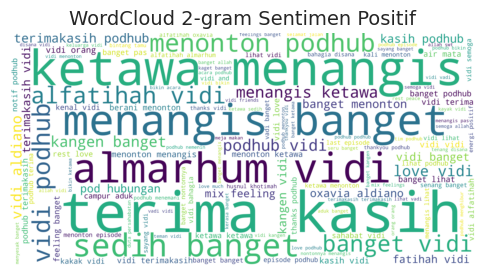

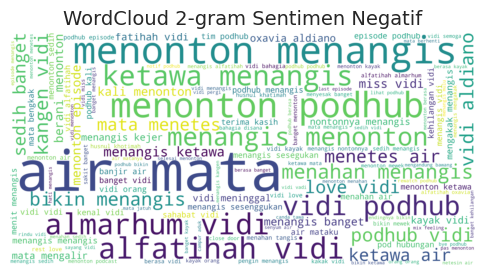

In [98]:
def wordcloud_ngram(data, sentiment_label, ngram_range=(2,3), max_words=1000):
    text_data = data[data['Sentiment'] == sentiment_label]['stopword removal']
    text_data = text_data.dropna()
    text_data = text_data[text_data.str.len() > 0]

    vectorizer = CountVectorizer(ngram_range=ngram_range)
    X = vectorizer.fit_transform(text_data)

    word_freq = dict(zip(
        vectorizer.get_feature_names_out(),
        X.sum(axis=0).A1
    ))

    # filter frekuensi kecil
    word_freq = {k: v for k, v in word_freq.items() if v > 2}

    wc = WordCloud(
        width=1000,
        height=500,
        background_color='white',
        max_words=max_words,
        prefer_horizontal=0.9,
        relative_scaling=0.5,
        collocations=False,
        min_font_size=8,
        max_font_size=120,
        scale=5
    ).generate_from_frequencies(word_freq)

    plt.figure(figsize=(6,4))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'WordCloud {ngram_range[0]}-gram Sentimen {sentiment_label}', fontsize=14)
    plt.show()

wordcloud_ngram(df, 'Positif', ngram_range=(2,2))
print()
wordcloud_ngram(df, 'Negatif', ngram_range=(2,2))

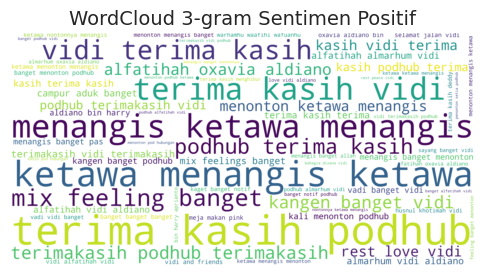

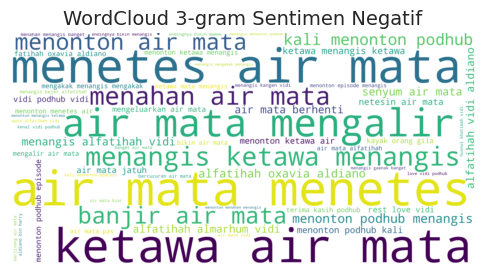

In [99]:
def wordcloud_ngram(data, sentiment_label, ngram_range=(2,3), max_words=1000):
    text_data = data[data['Sentiment'] == sentiment_label]['stopword removal']
    text_data = text_data.dropna()
    text_data = text_data[text_data.str.len() > 0]

    vectorizer = CountVectorizer(ngram_range=ngram_range)
    X = vectorizer.fit_transform(text_data)

    word_freq = dict(zip(
        vectorizer.get_feature_names_out(),
        X.sum(axis=0).A1
    ))

    # filter frekuensi kecil
    word_freq = {k: v for k, v in word_freq.items() if v > 2}

    wc = WordCloud(
        width=1000,
        height=500,
        background_color='white',
        max_words=max_words,
        prefer_horizontal=0.9,
        relative_scaling=0.5,
        collocations=False,
        min_font_size=8,
        max_font_size=120,
        scale=5
    ).generate_from_frequencies(word_freq)

    plt.figure(figsize=(6,4))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'WordCloud {ngram_range[0]}-gram Sentimen {sentiment_label}', fontsize=14)
    plt.show()

wordcloud_ngram(df, 'Positif', ngram_range=(3,3))
print()
wordcloud_ngram(df, 'Negatif', ngram_range=(3,3))

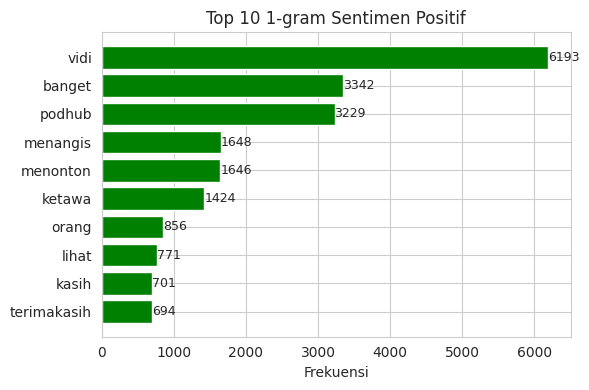

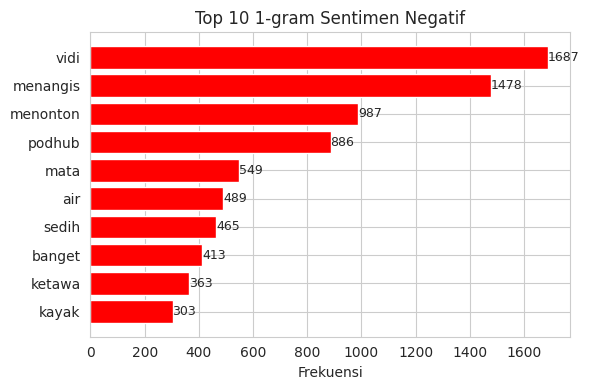

In [100]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

def plot_top_ngram(data, sentiment_label,
                   ngram_range=(2,2),
                   top_n=10,
                   color='blue'):

    text_data = data[data['Sentiment'] == sentiment_label]['stopword removal']

    vectorizer = CountVectorizer(ngram_range=ngram_range)
    X = vectorizer.fit_transform(text_data)

    freq_df = pd.DataFrame({
        'ngram': vectorizer.get_feature_names_out(),
        'frequency': X.sum(axis=0).A1
    }).sort_values(by='frequency', ascending=False).head(top_n)

    plt.figure(figsize=(6,4))
    bars = plt.barh(freq_df['ngram'], freq_df['frequency'], color=color)
    plt.gca().invert_yaxis()

    plt.xlabel('Frekuensi')
    plt.title(f'Top {top_n} {ngram_range[0]}-gram Sentimen {sentiment_label}')

    # 🔢 Label tepat di ujung bar
    for bar in bars:
        width = bar.get_width()
        plt.text(
            width,                              # tepat di ujung bar
            bar.get_y() + bar.get_height()/2,
            f'{int(width)}',
            va='center',
            ha='left',                          # teks keluar ke kanan
            fontsize=9
        )

    plt.tight_layout()
    plt.show()


# Pemanggilan
plot_top_ngram(df, 'Positif', ngram_range=(1,1), color='green')
print()
plot_top_ngram(df, 'Negatif', ngram_range=(1,1), color='red')

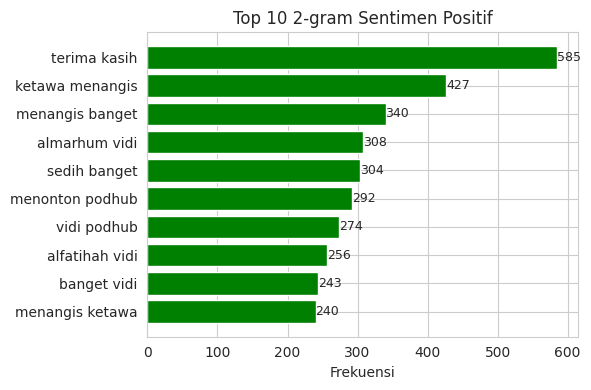

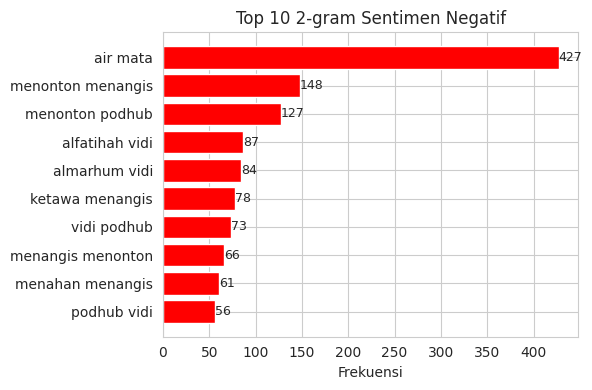

In [101]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

def plot_top_ngram(data, sentiment_label,
                   ngram_range=(2,2),
                   top_n=10,
                   color='blue'):

    text_data = data[data['Sentiment'] == sentiment_label]['stopword removal']

    vectorizer = CountVectorizer(ngram_range=ngram_range)
    X = vectorizer.fit_transform(text_data)

    freq_df = pd.DataFrame({
        'ngram': vectorizer.get_feature_names_out(),
        'frequency': X.sum(axis=0).A1
    }).sort_values(by='frequency', ascending=False).head(top_n)

    plt.figure(figsize=(6,4))
    bars = plt.barh(freq_df['ngram'], freq_df['frequency'], color=color)
    plt.gca().invert_yaxis()

    plt.xlabel('Frekuensi')
    plt.title(f'Top {top_n} {ngram_range[0]}-gram Sentimen {sentiment_label}')

    # 🔢 Label tepat di ujung bar
    for bar in bars:
        width = bar.get_width()
        plt.text(
            width,                              # tepat di ujung bar
            bar.get_y() + bar.get_height()/2,
            f'{int(width)}',
            va='center',
            ha='left',                          # teks keluar ke kanan
            fontsize=9
        )

    plt.tight_layout()
    plt.show()


# Pemanggilan
plot_top_ngram(df, 'Positif', ngram_range=(2,2), color='green')
print()
plot_top_ngram(df, 'Negatif', ngram_range=(2,2), color='red')

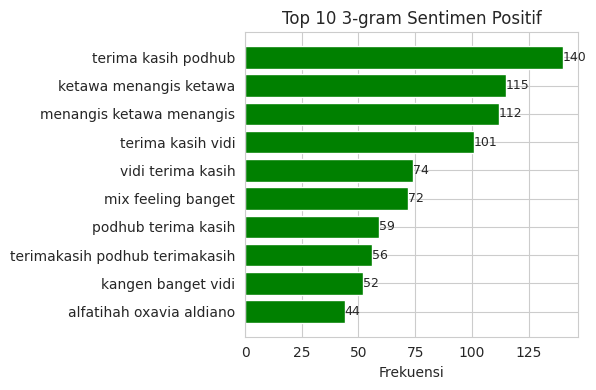

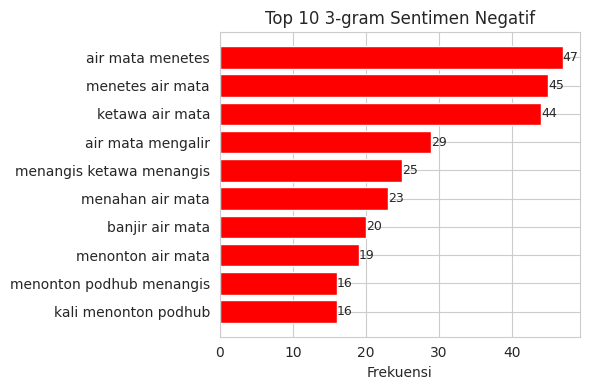

In [102]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

def plot_top_ngram(data, sentiment_label,
                   ngram_range=(2,2),
                   top_n=10,
                   color='blue'):

    text_data = data[data['Sentiment'] == sentiment_label]['stopword removal']

    vectorizer = CountVectorizer(ngram_range=ngram_range)
    X = vectorizer.fit_transform(text_data)

    freq_df = pd.DataFrame({
        'ngram': vectorizer.get_feature_names_out(),
        'frequency': X.sum(axis=0).A1
    }).sort_values(by='frequency', ascending=False).head(top_n)

    plt.figure(figsize=(6,4))
    bars = plt.barh(freq_df['ngram'], freq_df['frequency'], color=color)
    plt.gca().invert_yaxis()

    plt.xlabel('Frekuensi')
    plt.title(f'Top {top_n} {ngram_range[0]}-gram Sentimen {sentiment_label}')

    # 🔢 Label tepat di ujung bar
    for bar in bars:
        width = bar.get_width()
        plt.text(
            width,                              # tepat di ujung bar
            bar.get_y() + bar.get_height()/2,
            f'{int(width)}',
            va='center',
            ha='left',                          # teks keluar ke kanan
            fontsize=9
        )

    plt.tight_layout()
    plt.show()


# Pemanggilan
plot_top_ngram(df, 'Positif', ngram_range=(3,3), color='green')
print()
plot_top_ngram(df, 'Negatif', ngram_range=(3,3), color='red')

# ***2 class Inset Laxicon Based | Regresi Logistik, SVM, KNN, Naive Bayes, Random Forest, Decision Tree, dan Neural Network***

In [103]:
import pandas as pd

data = pd.read_csv("Hasil_Labelling_Data_Inset_Lax.csv")
data = data.dropna(subset=['stopword removal', 'Sentiment'])
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
Index: 12630 entries, 0 to 13046
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   stopword removal  12630 non-null  object
 1   Score             12630 non-null  int64 
 2   Sentiment         12630 non-null  object
dtypes: int64(1), object(2)
memory usage: 394.7+ KB


,stopword removal,Score,Sentiment
0,sebln menonton menangis aduhhhh terserah bilan...,-7,Negatif
1,kangen vidi dengar suara vadi,1,Positif
2,sedih yatapi hidup berjalan,-1,Negatif
3,cedih banget,0,Positif
4,cerita sedih balutt komediihebatt sahabt vidi,-1,Negatif


In [104]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

cleaned_data = data.dropna(subset=['stopword removal'])

X = cleaned_data['stopword removal']
y = cleaned_data['Sentiment']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Jumlah data latih:", len(X_train))
print("Jumlah data uji:", len(X_test))
print('===========================')

Jumlah data latih: 10104
Jumlah data uji: 2526


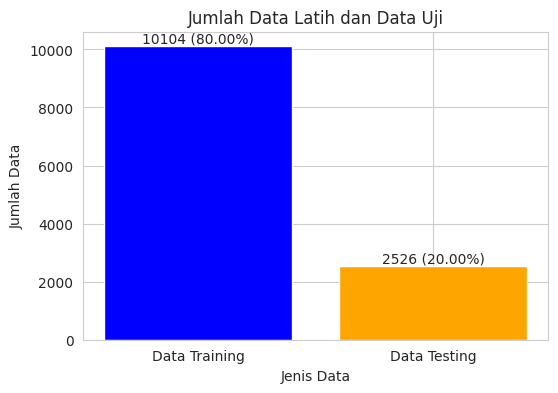

In [105]:
import matplotlib.pyplot as plt


train_size = len(X_train)
test_size = len(X_test)

plt.figure(figsize=(6, 4))
bars = plt.bar(['Data Training', 'Data Testing'], [train_size, test_size], color=['blue', 'orange'])

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height} ({height / (train_size + test_size) * 100:.2f}%)',
             ha='center', va='bottom')

plt.title('Jumlah Data Latih dan Data Uji')
plt.xlabel('Jenis Data')
plt.ylabel('Jumlah Data')
plt.show()


In [106]:
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

X_train_vec.shape, X_test_vec.shape

print("Jumlah fitur (kolom) setelah vektorisasi:", X_train_vec.shape[1])
print("Jumlah fitur (kolom) setelah vektorisasi:", X_test_vec.shape[1])

Jumlah fitur (kolom) setelah vektorisasi: 11802
Jumlah fitur (kolom) setelah vektorisasi: 11802


In [107]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt

# =========================================
# Inisialisasi Model
# =========================================
models = {
    "SVM": SVC(kernel='linear', random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Neural Network": MLPClassifier(random_state=42, hidden_layer_sizes=(100,), max_iter=500),
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42)
}

# =========================================
# Pelatihan & Evaluasi Model
# =========================================
results = {}

for model_name, model in models.items():
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)
    results[model_name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "classification_report": classification_report(y_test, y_pred, output_dict=True),
        "confusion_matrix": confusion_matrix(y_test, y_pred)
    }



Confusion Matrix for SVM:


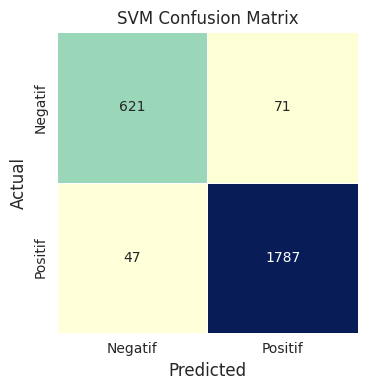


Confusion Matrix for KNN:


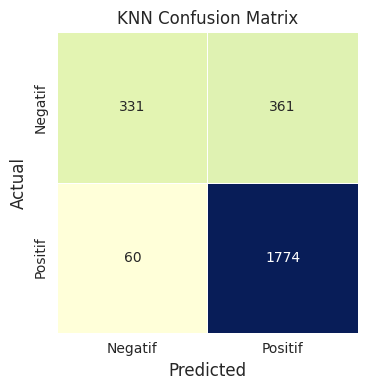


Confusion Matrix for Naive Bayes:


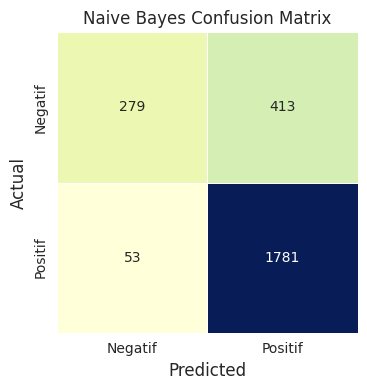


Confusion Matrix for Random Forest:


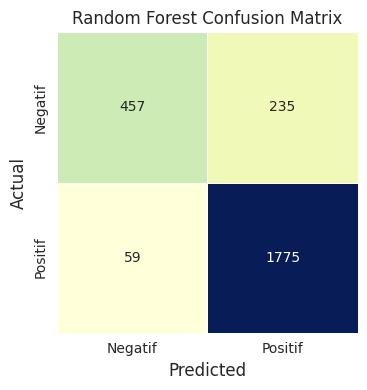


Confusion Matrix for Decision Tree:


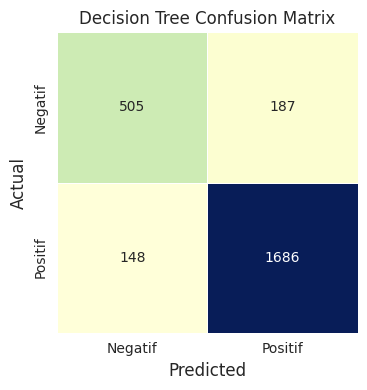


Confusion Matrix for Neural Network:


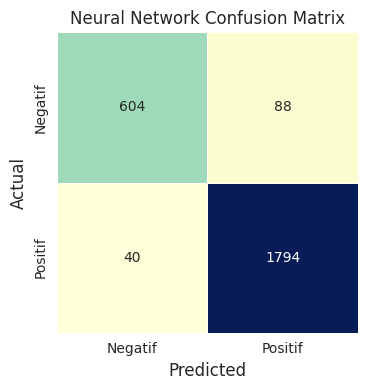


Confusion Matrix for Logistic Regression:


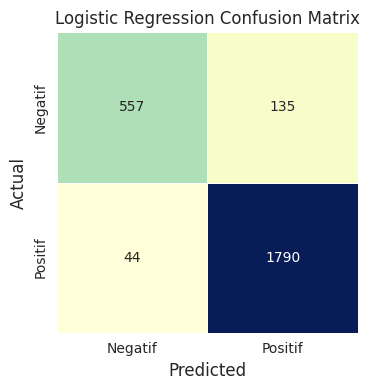

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

for model_name, result in results.items():
    fig, ax = plt.subplots(figsize=(4, 4))
    sns.heatmap(
        result["confusion_matrix"],
        annot=True,
        fmt='d',
        cmap="YlGnBu",
        cbar=False,
        xticklabels=['Negatif','Positif'],
        yticklabels=['Negatif','Positif'],
        ax=ax,
        square=True,
        linewidths=0.5
    )
    print(f"\nConfusion Matrix for {model_name}:")
    ax.set_title(f"{model_name} Confusion Matrix", fontsize=12)
    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("Actual", fontsize=12)


    plt.tight_layout()
    plt.show()


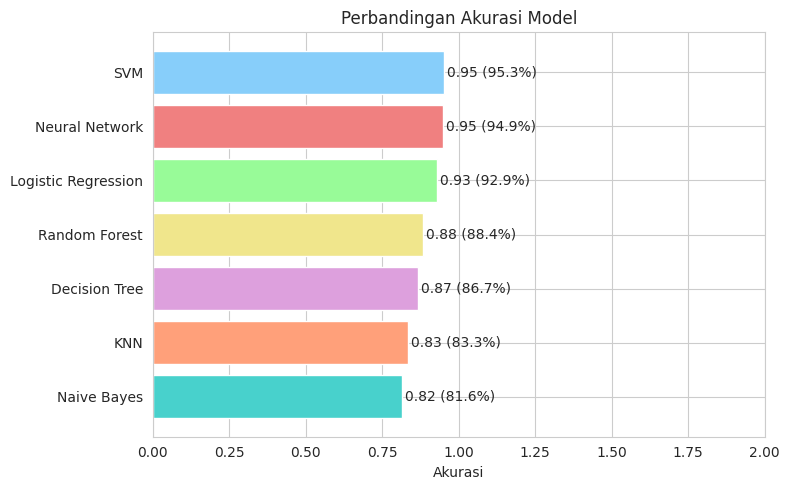

In [109]:
import matplotlib.pyplot as plt

# Urutkan berdasarkan nilai akurasi (dari besar ke kecil)
accuracies = {model: result['accuracy'] for model, result in results.items()}
sorted_accuracies = dict(sorted(accuracies.items(), key=lambda item: item[1], reverse=True))

# Warna terang cerah (bright colors)
bright_colors = [
    'lightskyblue', 'lightcoral', 'palegreen', 'khaki',
    'plum', 'lightsalmon', 'mediumturquoise', 'wheat'
]

# Sesuaikan jumlah warna dengan jumlah model
num_models = len(sorted_accuracies)
colors = bright_colors[:num_models] if num_models <= len(bright_colors) else bright_colors * (num_models // len(bright_colors) + 1)

plt.figure(figsize=(8, 5))

# Buat bar horizontal dengan warna terang
bars = plt.barh(
    list(sorted_accuracies.keys()),
    list(sorted_accuracies.values()),
    color=colors[:num_models]
)

# Tambahkan nilai akurasi di setiap bar
for bar in bars:
    accuracy = bar.get_width()
    plt.text(
        accuracy + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{accuracy:.2f} ({accuracy * 100:.1f}%)',
        va='center',
        fontsize=10
    )

plt.title("Perbandingan Akurasi Model")
plt.xlabel("Akurasi")
plt.xlim(0, 2)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [110]:
from IPython.display import display

for model_name, result in results.items():
    print(f"\nClassification Report for {model_name}:")

    report_df = pd.DataFrame(result['classification_report']).transpose()

    styled_df = report_df.style.background_gradient(cmap="coolwarm")
    styled_df = styled_df.format(precision=3)
    display(styled_df)


Classification Report for SVM:


,precision,recall,f1-score,support
Negatif,0.930,0.897,0.913,692.000
Positif,0.962,0.974,0.968,1834.000
accuracy,0.953,0.953,0.953,0.953
macro avg,0.946,0.936,0.941,2526.000
weighted avg,0.953,0.953,0.953,2526.000



Classification Report for KNN:


,precision,recall,f1-score,support
Negatif,0.847,0.478,0.611,692.000
Positif,0.831,0.967,0.894,1834.000
accuracy,0.833,0.833,0.833,0.833
macro avg,0.839,0.723,0.753,2526.000
weighted avg,0.835,0.833,0.816,2526.000



Classification Report for Naive Bayes:


...

,precision,recall,f1-score,support
Negatif,0.773,0.730,0.751,692.000
Positif,0.900,0.919,0.910,1834.000
accuracy,0.867,0.867,0.867,0.867
macro avg,0.837,0.825,0.830,2526.000
weighted avg,0.865,0.867,0.866,2526.000



Classification Report for Neural Network:


,precision,recall,f1-score,support
Negatif,0.938,0.873,0.904,692.000
Positif,0.953,0.978,0.966,1834.000
accuracy,0.949,0.949,0.949,0.949
macro avg,0.946,0.926,0.935,2526.000
weighted avg,0.949,0.949,0.949,2526.000



Classification Report for Logistic Regression:


,precision,recall,f1-score,support
Negatif,0.927,0.805,0.862,692.000
Positif,0.930,0.976,0.952,1834.000
accuracy,0.929,0.929,0.929,0.929
macro avg,0.928,0.890,0.907,2526.000
weighted avg,0.929,0.929,0.928,2526.000
